Data Set: Retail Sales Dataset

1. Transaction ID: A unique identifier for each transaction, allowing tracking and reference.
2. Date: The date when the transaction occurred, providing insights into sales trends over time.
3. Customer ID: A unique identifier for each customer, enabling customer-centric analysis.
4. Gender: The gender of the customer (Male/Female), offering insights into gender-based purchasing patterns.
5. Age: The age of the customer, facilitating segmentation and exploration of age-related influences.
6. Product Category: The category of the purchased product (e.g., Electronics, Clothing, Beauty), helping understand product preferences.
7. Quantity: The number of units of the product purchased, contributing to insights on purchase volumes.
8. Price per Unit: The price of one unit of the product, aiding in calculations related to total spending.
9. Total Amount: The total monetary value of the transaction, showcasing the financial impact of each purchase.

Source: https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset

In [23]:
'''
Import modul yang dibutuhkan
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression, ElasticNet, HuberRegressor, RANSACRegressor, TheilSenRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [24]:
!pip install kaggle

In [25]:
!kaggle datasets download mohammadtalib786/retail-sales-dataset

Dataset URL: https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset
License(s): CC0-1.0
retail-sales-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [26]:
!unzip retail-sales-dataset.zip

Archive:  retail-sales-dataset.zip
replace retail_sales_dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [27]:
'''
Read file CSV
'''

df = pd.read_csv('/content/retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [28]:
'''
Data shape
'''
df.shape

(1000, 9)

In [29]:
'''
Data Info
'''
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [30]:
'''
Mengubah Tipe Data Date menjadi date time dan membuat fitur baru dengan nama month, day, dan year
'''

df.Date = pd.to_datetime(df.Date,format = '%Y-%m-%d')
df['month'] = df.Date.dt.month
df['day'] = df.Date.dt.day
df['year'] = df.Date.dt.year

'''
Melihat info data terbaru
'''

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   month             1000 non-null   int32         
 10  day               1000 non-null   int32         
 11  year              1000 non-null   int32         
dtypes: datetime64[ns](1), int32(3), int64(5), object(3)
memory usage: 82.2+ KB


In [31]:
'''
Statistik Deskriptif Data
'''

df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,month,day,year
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,6.549000,15.310000,2023.002000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,1.000000,1.000000,2023.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,4.000000,7.000000,2023.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,6.000000,15.000000,2023.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,10.000000,23.000000,2023.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,12.000000,31.000000,2024.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,3.452755,8.871674,0.044699


In [32]:
'''
Menghitung jumlah NaN atau missing data
'''

df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0
month,0


In [33]:
'''
Menghitung duplikasi data
'''

df.duplicated().value_counts()

,count
False,1000


In [34]:
'''
Data Numerikal
'''

num_df = df.select_dtypes(include=['int64'])
num_df.head()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,34,3,50,150
1,2,26,2,500,1000
2,3,50,1,30,30
3,4,37,1,500,500
4,5,30,2,50,100


In [35]:
'''
Data Kategorikal
'''

cat_df = df.drop(num_df, axis = 1)
cat_df.head()

,Date,Customer ID,Gender,Product Category,month,day,year
0,2023-11-24,CUST001,Male,Beauty,11,24,2023
1,2023-02-27,CUST002,Female,Clothing,2,27,2023
2,2023-01-13,CUST003,Male,Electronics,1,13,2023
3,2023-05-21,CUST004,Male,Clothing,5,21,2023
4,2023-05-06,CUST005,Male,Beauty,5,6,2023


Visualisasi distribusi setiap fitur/variabel

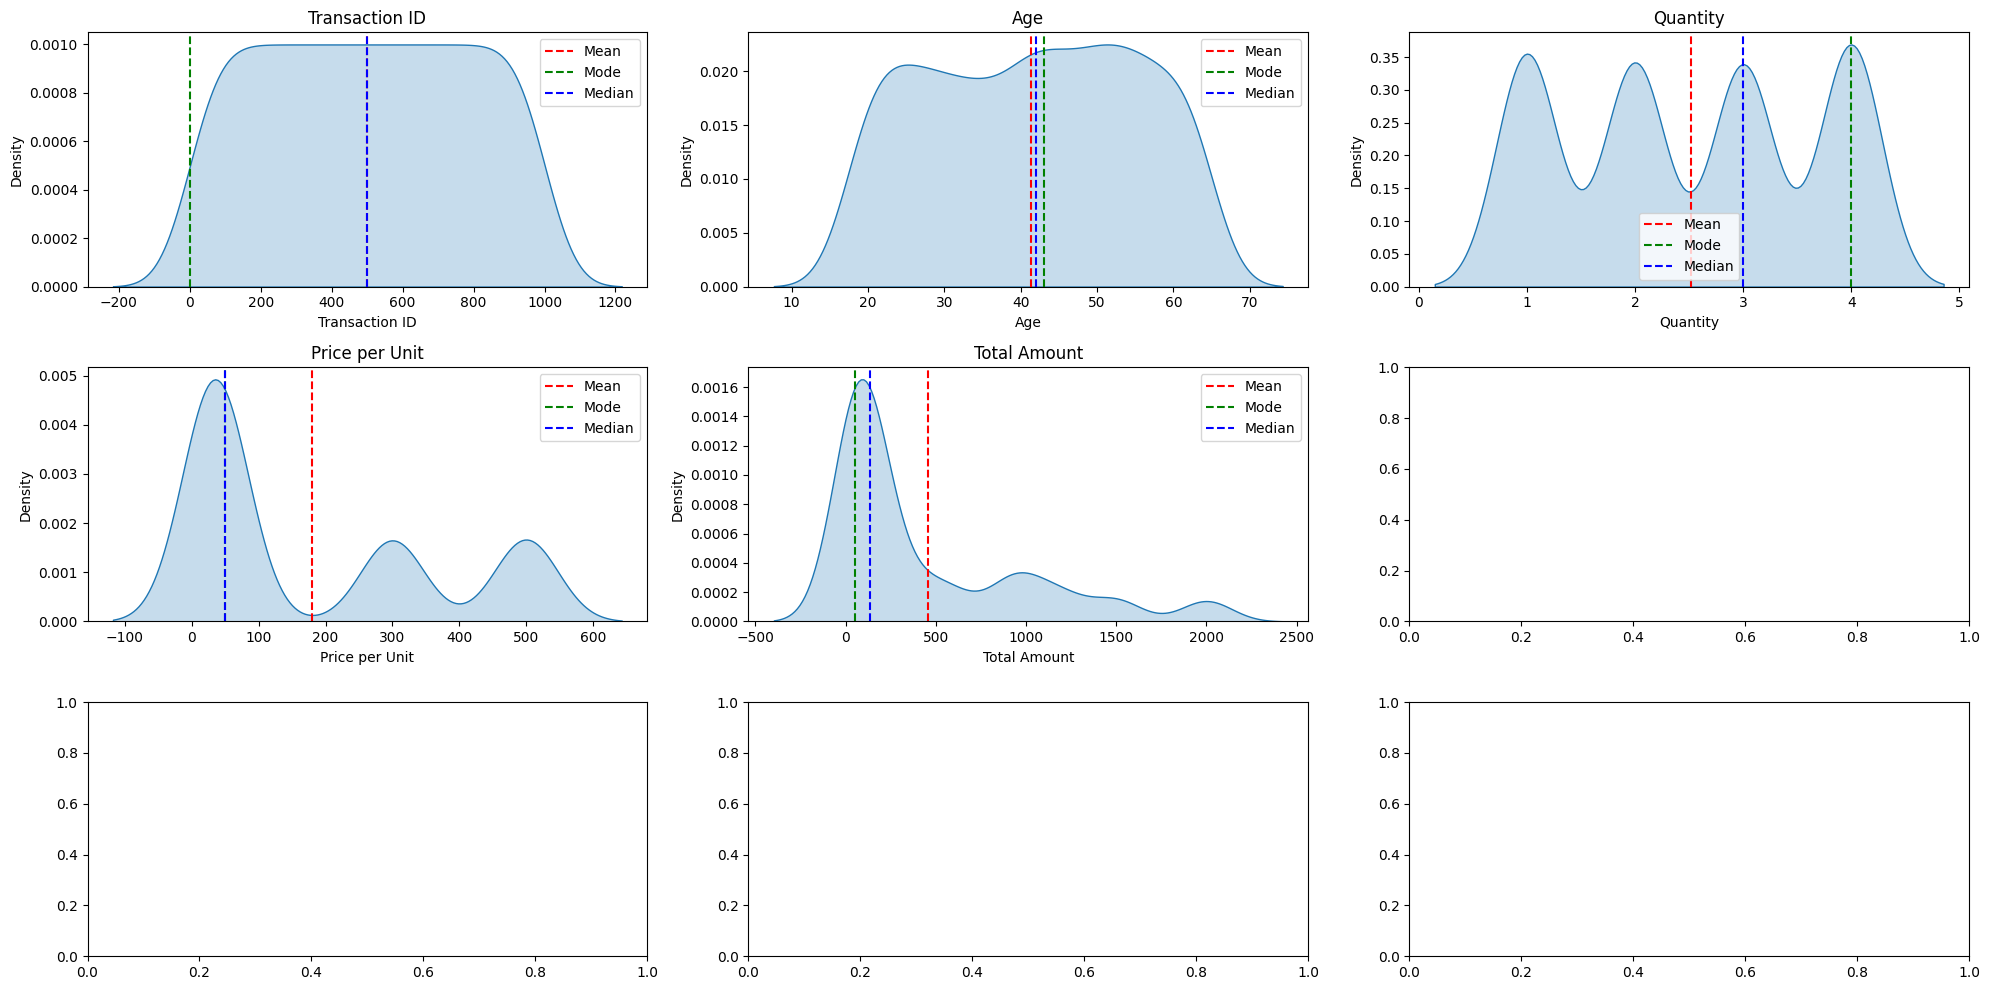

In [36]:
'''
Distribusi Data Numerikal
'''

fig, axes = plt.subplots(3, 3, figsize=(20, 10))

for i, attr in enumerate(num_df):
    row = i // 3
    col = i % 3
    sns.kdeplot(data=num_df[attr], ax=axes[row, col], fill=True)
    axes[row, col].set_title(attr)

    mean_val = num_df[attr].mean()
    mode_val = num_df[attr].mode().iloc[0]
    median_val = num_df[attr].median()

    axes[row, col].axvline(mean_val, color='r', linestyle='--', label='Mean')
    axes[row, col].axvline(mode_val, color='g', linestyle='--', label='Mode')
    axes[row, col].axvline(median_val, color='b', linestyle='--', label='Median')

    axes[row, col].legend()

plt.tight_layout()

plt.show()

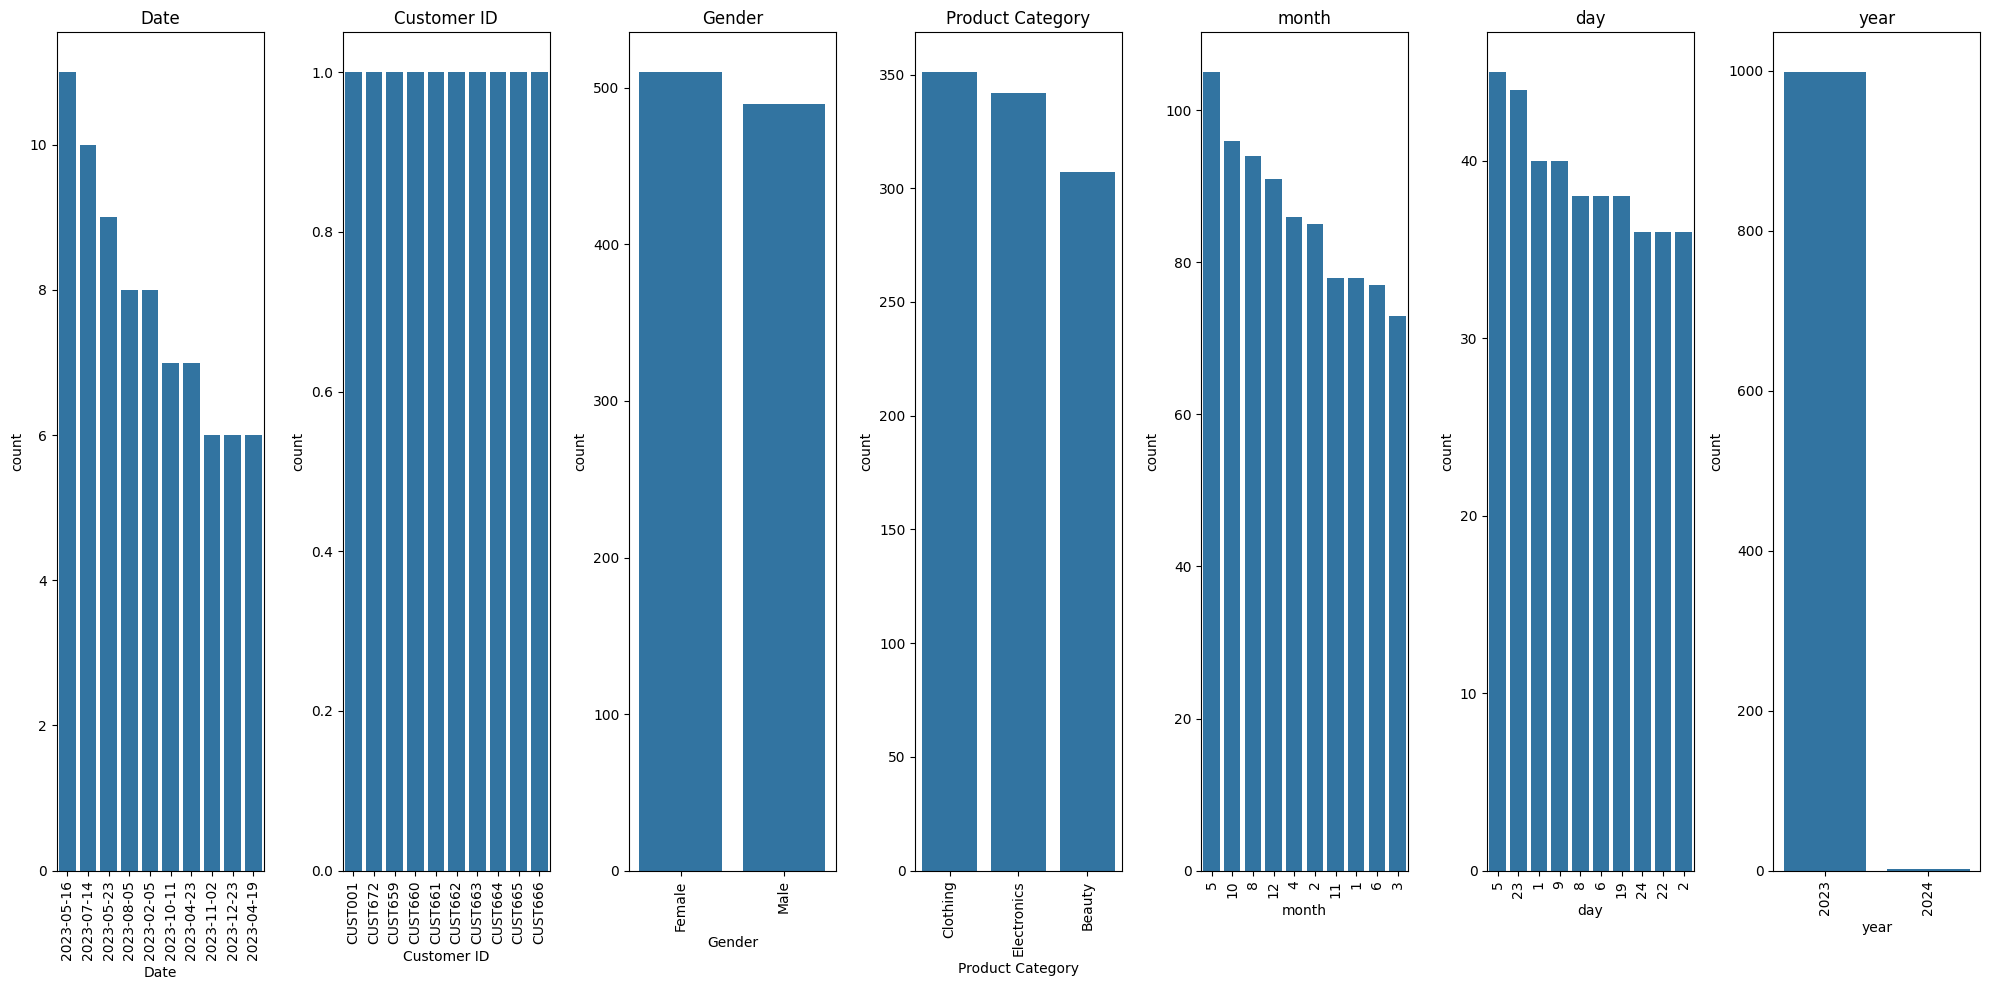

In [37]:
'''
Distribusi Data Kategorikal
'''

plt.figure(figsize=(20, 10))

for i, column in enumerate(cat_df.columns):
    plt.subplot(1, 7, i+1)
    top_10_values = cat_df[column].value_counts().head(10)
    sns.countplot(data=cat_df, x=column, order=top_10_values.index)
    plt.title(column)
    plt.xticks(rotation='vertical')

plt.tight_layout()
plt.show()

### Siapakah Top 10 spender dan berapa total transaksinya?



Berdasarkan hasil analisis, top 10 spender diisi oleh  CUST487, CUST476, CUST773, CUST503, CUST093, CUST089, CUST946, CUST157, CUST155, dan CUST420 dengan semua total transaksi sama, yaitu 2000.

In [38]:
'''
Melakukan Grouping untuk melihat Customer dengan Total Amount terbesar.
Dalam proses grouping saya menyertakan data Product Category, Price per Unit, dan Quantity untuk melihat rincian dari Total Amount tiap Customers.
'''

top_10_Spender = df.groupby(['Customer ID', 'Product Category', 'Price per Unit', 'Quantity'])['Total Amount'].sum().sort_values(ascending=False).head(10).reset_index()
top_10_Spender

,Customer ID,Product Category,Price per Unit,Quantity,Total Amount
0,CUST487,Clothing,500,4,2000
1,CUST476,Clothing,500,4,2000
2,CUST773,Electronics,500,4,2000
3,CUST503,Beauty,500,4,2000
4,CUST093,Beauty,500,4,2000
5,CUST089,Electronics,500,4,2000
6,CUST946,Electronics,500,4,2000
7,CUST157,Electronics,500,4,2000
8,CUST155,Electronics,500,4,2000
9,CUST420,Clothing,500,4,2000


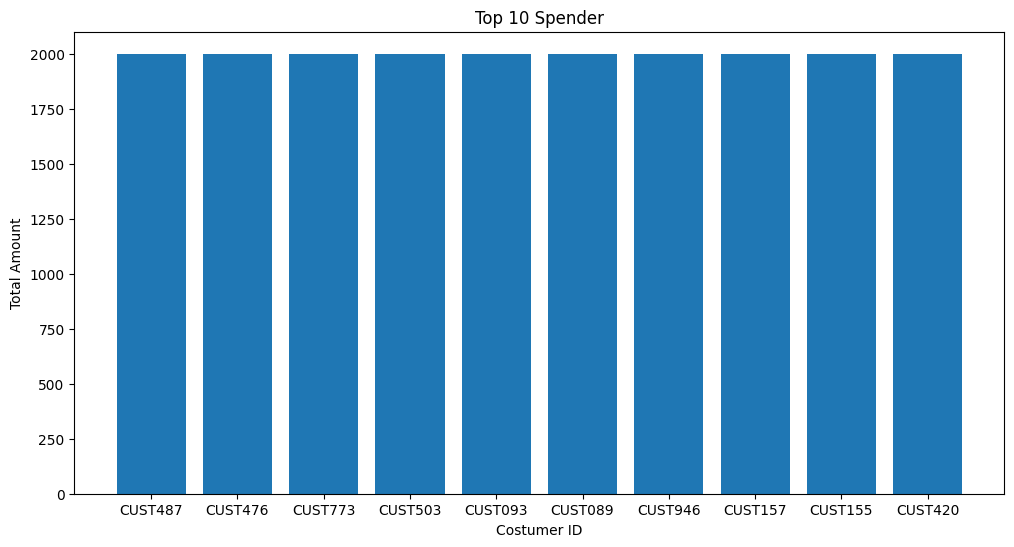

In [39]:
'''
Plot Bar
'''
'''
Pada Top 10 Spender, saya menggunakan plot bar karena agar mempermudah perbandingan, antara 1 customers dengan
customers lainnya, walau pada kasus kali ini top 10 spender memiliki total amount yang sama, namun visualisasi bar
membantu melihat perbedan antar CUST ID
'''

plt.figure(figsize=(12, 6))
plt.bar(top_10_Spender['Customer ID'], top_10_Spender['Total Amount'])
plt.title('Top 10 Spender')
plt.xlabel('Costumer ID')
plt.ylabel('Total Amount')
plt.show()

### Bagaimana demografi orang yang membeli barang dengan kategori elektronik?



Pada visualisasi demografi, saya menggunakan visualisasi dengan grafik batang dan grafik pie, saya menggunakan kedua agar jumlah data akan divisualisasikan oleh grafik batang dan persentase dari tiap fitur pada tiap kelompok akan divisualisasikan oleh grafik pie

In [40]:
'''
Membuat variable baru untuk hasil filtering data berdasarkan product category Electronics
'''

electronic_Cust = df[df['Product Category'] == 'Electronics']
electronic_Cust

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month,day,year
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,13,2023
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100,2,22,2023
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600,12,13,2023
12,13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500,8,5,2023
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000,1,16,2023
...,...,...,...,...,...,...,...,...,...,...,...,...
988,989,2023-12-28,CUST989,Female,44,Electronics,1,25,25,12,28,2023
991,992,2023-08-21,CUST992,Female,57,Electronics,2,30,60,8,21,2023
992,993,2023-02-06,CUST993,Female,48,Electronics,3,50,150,2,6,2023
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12,5,2023


#### Demographic Based on Gender

In [41]:
'''
Menghitung value Gender
'''

electronic_cust_demography_Gender = electronic_Cust['Gender'].value_counts()
electronic_cust_demography_Gender

,count
Gender,
Male,172
Female,170


Text(0.5, 1.03, 'Demographics of Electronics Buyers Based On Gender')

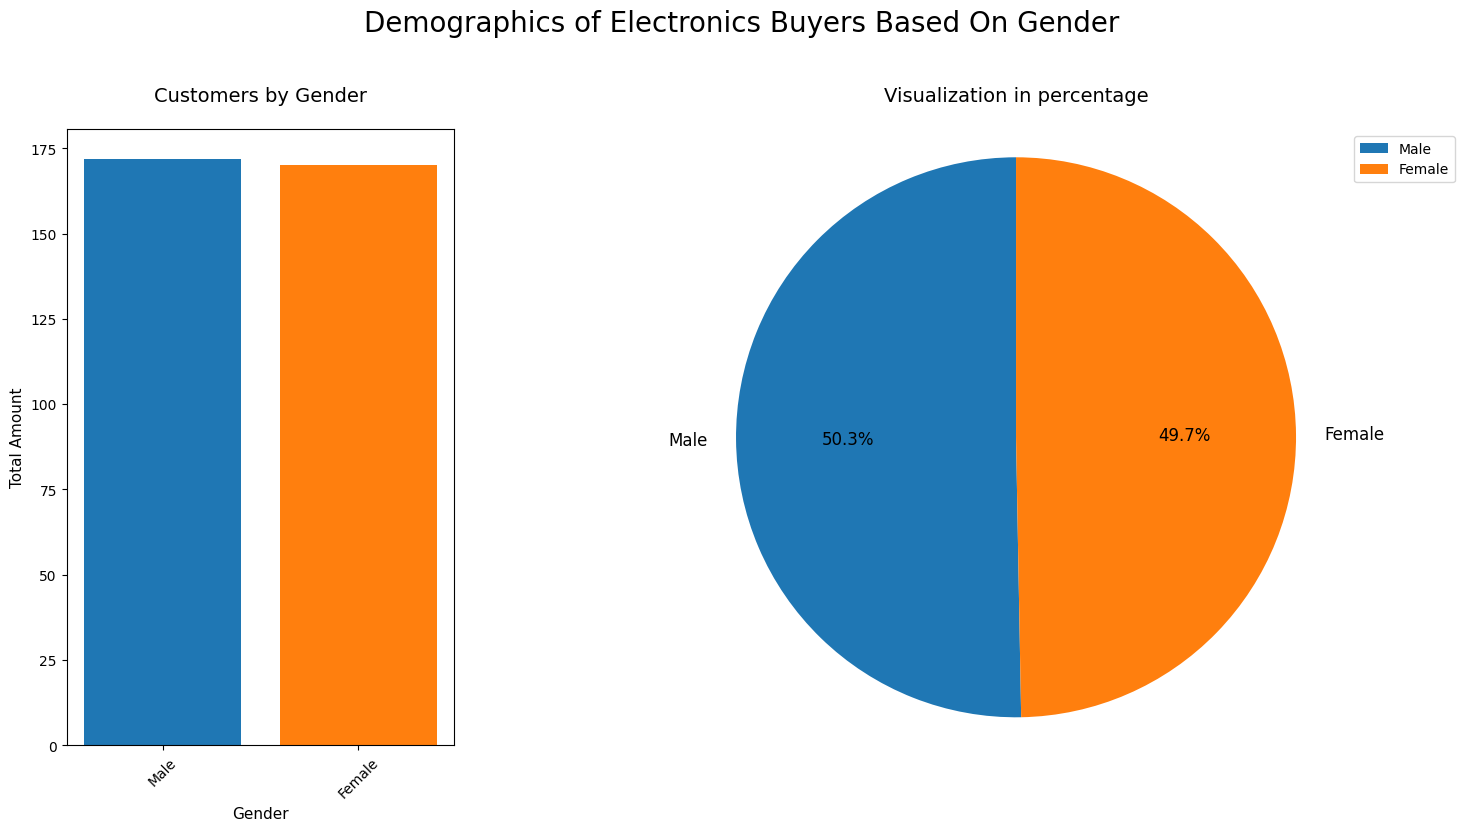

In [42]:
grid = plt.GridSpec(1, 3, wspace=0.3, hspace = 0.3)

plt.figure(figsize=(18,8))

plt.subplot(grid[0, 0])
plt.bar(electronic_cust_demography_Gender.index, electronic_cust_demography_Gender.values, color=['#1f77b4', '#ff7f0e'])
plt.xlabel('Gender', fontsize = 11)
plt.ylabel('Total Amount', fontsize = 11)
plt.xticks(rotation=45)
plt.title('Customers by Gender', fontsize = 14, pad=20)


plt.subplot(grid[0, 1:])
plt.pie(electronic_cust_demography_Gender, labels=electronic_cust_demography_Gender.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
plt.axis('equal')
plt.title('Visualization in percentage', fontsize = 14, pad=20)
plt.legend()

plt.suptitle('Demographics of Electronics Buyers Based On Gender', fontsize=20, y=1.03)

Berdasarkan hasil visualisasi perbandingan antara Male dan Female bisa dikatakan hanya memiliki sedikit perbedaan, yaitu Male dengan 50.3% dan Female dengan 49.7%. Dalam ukuran angkapun perbedaan kedua gender hanya berbeda 2, yaitu Male dengan 172 orang dan Female dengan 170 orang.

#### Demographic Based on Age

In [43]:
'''
Menghitung value Age
'''

electronic_cust_demography_Age = electronic_Cust.groupby('Age').size()
electronic_cust_demography_Age.head()

,0
Age,
18,5
19,11
20,7
21,4
22,10


In [44]:
'''
Melakukan kategorikan pada umur
'''

bins = [18, 25, 30, 35, 40, 50, 60, 70]

electronic_Cust['Age'] = pd.cut(electronic_Cust['Age'], bins=bins, labels=['18-24', '25-29', '30-34', '35-39', '40-49', '50-59', '60-69'])

electronic_Cust

<ipython-input-44-d2938a361423>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  electronic_Cust['Age'] = pd.cut(electronic_Cust['Age'], bins=bins, labels=['18-24', '25-29', '30-34', '35-39', '40-49', '50-59', '60-69'])


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month,day,year
2,3,2023-01-13,CUST003,Male,40-49,Electronics,1,30,30,1,13,2023
7,8,2023-02-22,CUST008,Male,25-29,Electronics,4,25,100,2,22,2023
8,9,2023-12-13,CUST009,Male,60-69,Electronics,2,300,600,12,13,2023
12,13,2023-08-05,CUST013,Male,18-24,Electronics,3,500,1500,8,5,2023
14,15,2023-01-16,CUST015,Female,40-49,Electronics,4,500,2000,1,16,2023
...,...,...,...,...,...,...,...,...,...,...,...,...
988,989,2023-12-28,CUST989,Female,40-49,Electronics,1,25,25,12,28,2023
991,992,2023-08-21,CUST992,Female,50-59,Electronics,2,30,60,8,21,2023
992,993,2023-02-06,CUST993,Female,40-49,Electronics,3,50,150,2,6,2023
998,999,2023-12-05,CUST999,Female,35-39,Electronics,3,50,150,12,5,2023


In [45]:
'''
Menghitung value Age berdasarkan kategori
'''

electronic_cust_demography_Age = electronic_Cust.groupby('Age').size()
electronic_cust_demography_Age.head()

<ipython-input-45-5423fa3d0e95>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  electronic_cust_demography_Age = electronic_Cust.groupby('Age').size()


,0
Age,
18-24,53
25-29,30
30-34,34
35-39,34
40-49,74


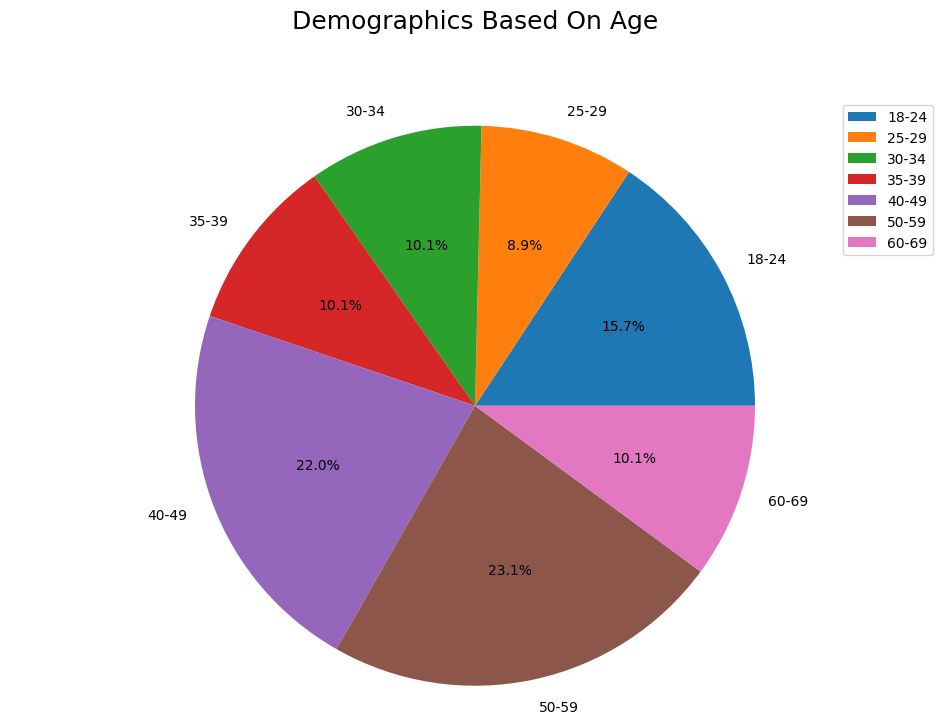

In [46]:
'''
Plot Pie
'''

plt.figure(figsize=(12, 8))
plt.pie(electronic_cust_demography_Age, labels=electronic_cust_demography_Age.index, autopct='%1.1f%%', startangle=0)
plt.title('Demographics Based On Age', fontsize=18, pad=50)
plt.legend(loc='upper right')
plt.axis('equal')
plt.show()

Berdasarkan hasil visualisasi, pembeli elektronik tertinggi berdasarkan umur berada pada rentang umur 50-59 tahun dengan 23.1%, diikuti dengan 40-49 tahun dengan 22.0%, diikuti dengan 18-24 tahun dengan 15.7%.

Pembeli dengan rentang umut 35-39, 60-69, dan 30-34 tahun memiliki persentase dengan nilai yang sama, yaitu 10.1%. Rentang umur 25-29 tahun berada di posisi terakhir dengan 8.9%

Text(0.5, 1.0, 'Customers by Gender')

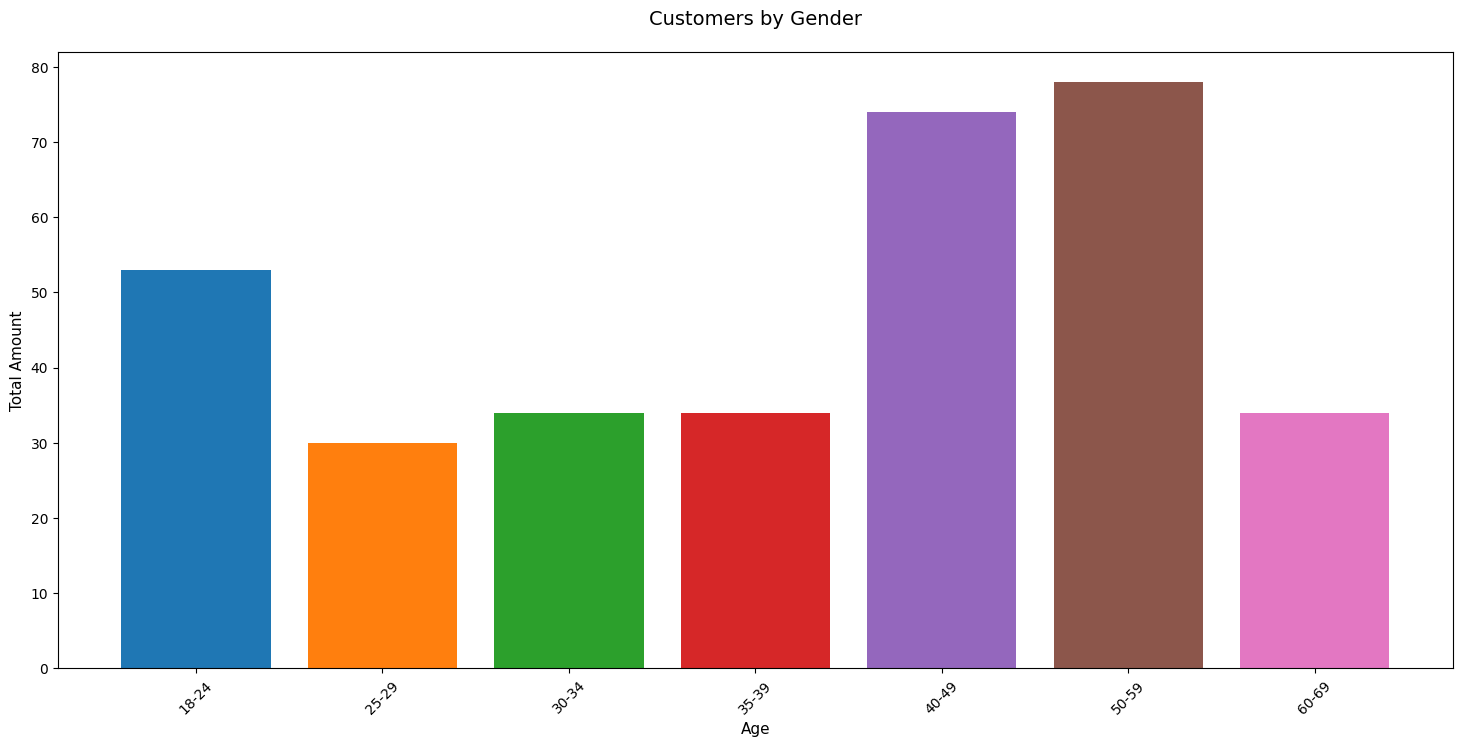

In [70]:
'''
Plot Bar
'''

plt.figure(figsize=(18,8))
plt.bar(electronic_cust_demography_Age.index, electronic_cust_demography_Age.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'])
plt.xlabel('Age', fontsize = 11)
plt.ylabel('Total Amount', fontsize = 11)
plt.xticks(rotation=45)
plt.title('Customers by Age', fontsize = 14, pad=20)

Berdasarkan hasil visualisasi, pembeli elektronik dengan rentang umur 50-59, 40-49, dan 18-24 berada di posisi pertama, kedua, dan ketiga, dengan jumlah pembeli 79 orang, 74 orang, dan 53 orang. Pembeli dengan rentang umur 30-34, 35-39, dan 60-69 memiliki jumlah pembeli yang sama, yaitu masing masing 34 orang. Rentang umur 25-29 tahun berada di tempat terakhir dengan 30 orang.

### Kategori produk apa yang paling signifikan dalam memberikan Gross evenue?


Pada visualisasi gross value, saya juga menggunakan visualisasi dengan grafik batang dan grafik pie, saya menggunakan kedua agar jumlah data akan divisualisasikan oleh grafik batang dan persentase dari tiap fitur akan divisualisasikan oleh grafik pie

In [48]:
revenueByProducts = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).reset_index()
revenueByProducts

,Product Category,Total Amount
0,Electronics,156905
1,Clothing,155580
2,Beauty,143515


Text(0.5, 1.03, 'Total Revenue Distribution by Product Category')

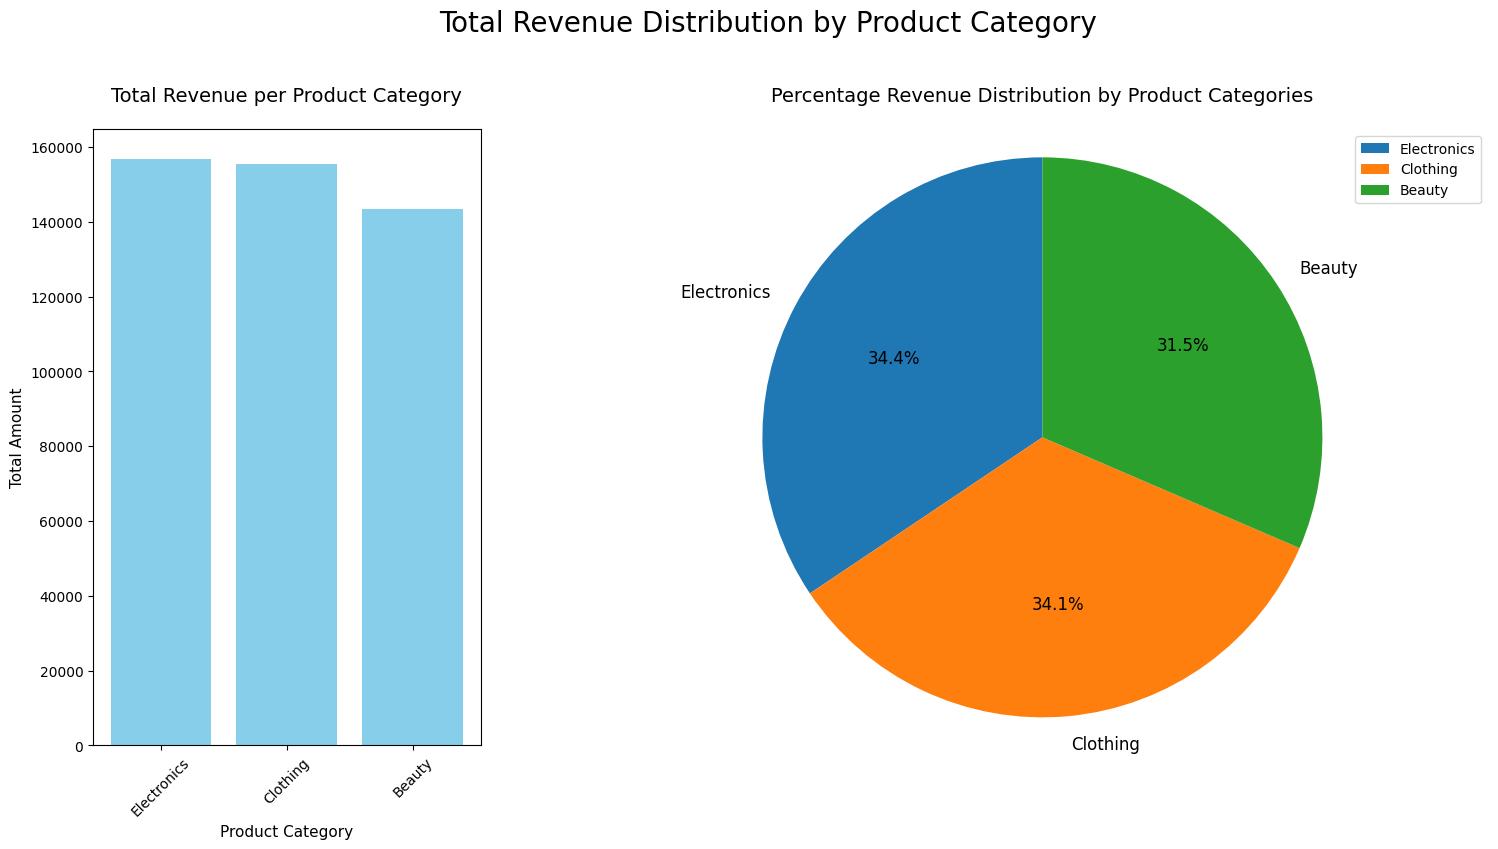

In [49]:
grid = plt.GridSpec(1, 3, wspace=0.3, hspace = 0.3)

plt.figure(figsize=(18,8))

plt.subplot(grid[0, 0])
plt.bar(revenueByProducts['Product Category'], revenueByProducts['Total Amount'], color='skyblue')
plt.xlabel('Product Category', fontsize = 11)
plt.ylabel('Total Amount', fontsize = 11)
plt.xticks(rotation=45)
plt.title('Total Revenue per Product Category', fontsize = 14, pad=20)

plt.subplot(grid[0, 1:])
plt.pie(revenueByProducts['Total Amount'], labels=revenueByProducts['Product Category'], autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
plt.axis('equal')
plt.title('Percentage Revenue Distribution by Product Categories', fontsize = 14, pad=20)
plt.legend()

plt.suptitle('Total Revenue Distribution by Product Category', fontsize=20, y=1.03)

Berdasarkan visualisasi, Electronics menyumbangkan revenue dengan persentase terbesar, dengan 34.4%, diikuti dengan Clothing dengan 34.1%, dan di tempat terakhir Beauty dengan 31.5%.

Dalam total amountnya Electronics mengumpulkan 156905, Clothing mengumpulkan 155589, dan Beauty mengumpulkan 143515.

### Bagaimana tren penjualan dari waktu ke waktu? Apakah terdapat peningkatan di suatu tanggal tertentu?



Pada visualisasi tren penjualan, saya menggunakan plot line untuk melihat tren dan pola dalam data yang berubah seiring waktu, berdasarkan data yang ada, terjadi peningkatan penjualan pada bulan ke 5.

In [53]:
Sales_trends = df.groupby(['month'])[['Quantity', 'Total Amount']].sum().reset_index()
Sales_trends

,month,Quantity,Total Amount
0,1,199,36980
1,2,214,44060
2,3,194,28990
3,4,214,33870
4,5,259,53150
5,6,197,36715
6,7,176,35465
7,8,227,36960
8,9,170,23620
9,10,252,46580


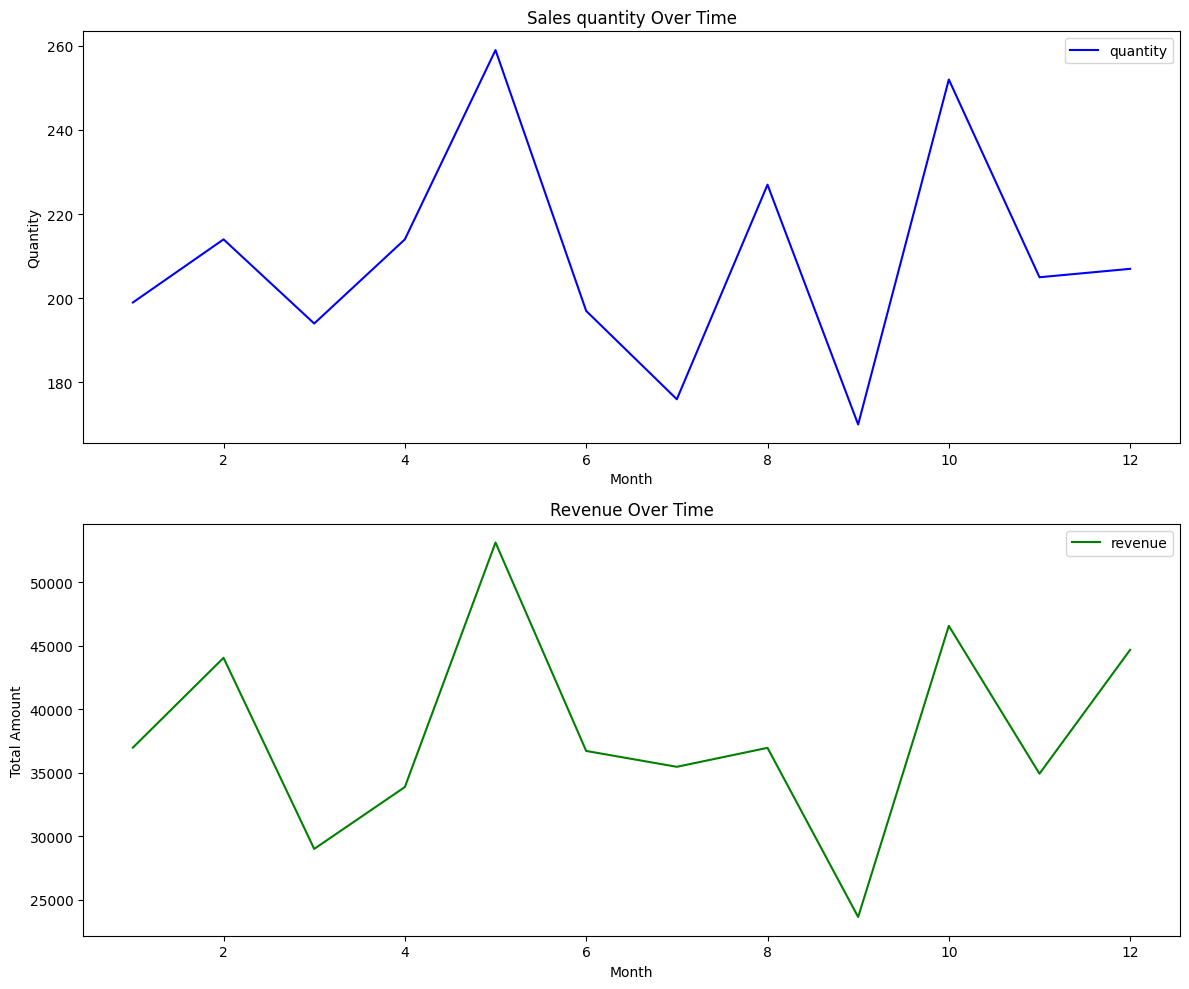

In [54]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.plot(Sales_trends['month'], Sales_trends['Quantity'], label='quantity', color='blue')
plt.title('Sales quantity Over Time')
plt.ylabel('Quantity')
plt.xlabel('Month')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(Sales_trends['month'], Sales_trends['Total Amount'], label='revenue',color='green')
plt.title('Revenue Over Time')
plt.ylabel('Total Amount')
plt.xlabel('Month')
plt.legend()

plt.subplots_adjust(hspace=3)

plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi

1. Kuantitas sales berada dilevel tertinggi pada bulan ke 5, hal ini berbanding lurus dengan jumlah revenue yang didapatkan.
2. Kuantitas sales berada dilevel terendah pada bulan ke 9, hal ini berbanding lurus dengan jumlah revenue yang didapatkan.
3. Data selama 12 bulan ini mengalami fluktuasi

##Kategori produk apa yang terjual paling banyak?

Pada visualisasi penjualan, saya menggunakan plot bar agar value tiap variabel dapat dilihat secara lebih baik. Sebenarnya bisa menggunakan line chart, namum preferensi saya menggunakan plot bar.

In [55]:
ProdbyTy = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False).reset_index()
ProdbyTy

,Product Category,Quantity
0,Clothing,894
1,Electronics,849
2,Beauty,771


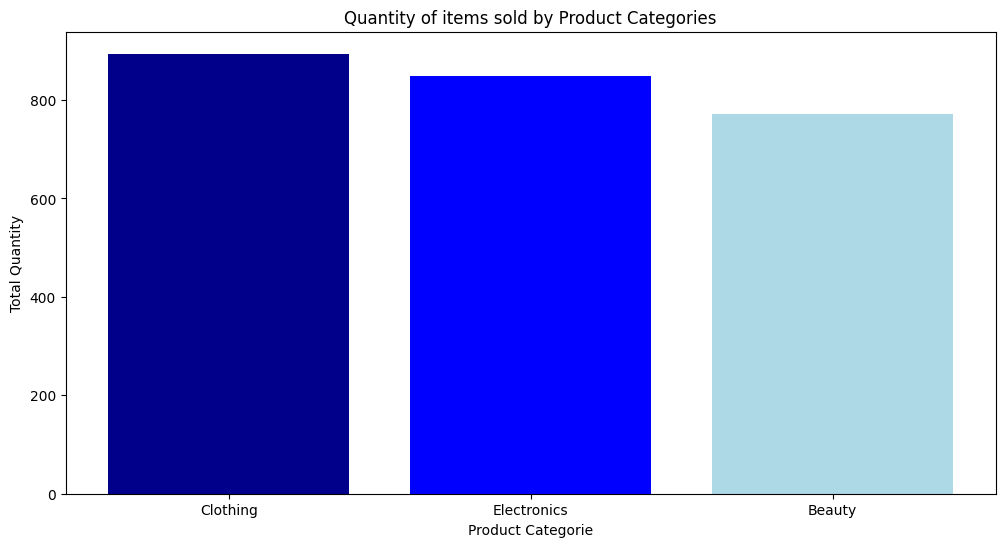

In [56]:
'''
Plot Bar
'''

plt.figure(figsize=(12, 6))
plt.bar(ProdbyTy['Product Category'], ProdbyTy['Quantity'], color=['darkblue', 'blue', 'lightblue'])
plt.title('Quantity of items sold by Product Categories')
plt.xlabel('Product Categorie')
plt.ylabel('Total Quantity')
plt.show()

Berdasarkan hasil visualisasi clothing merupakan kategori produk terlaris, diikuti dengan ELectronics di posisi kedua, dan Beauty di posisi ketiga.

## Total pengeluaran pada kategori produk berdasarkan gender

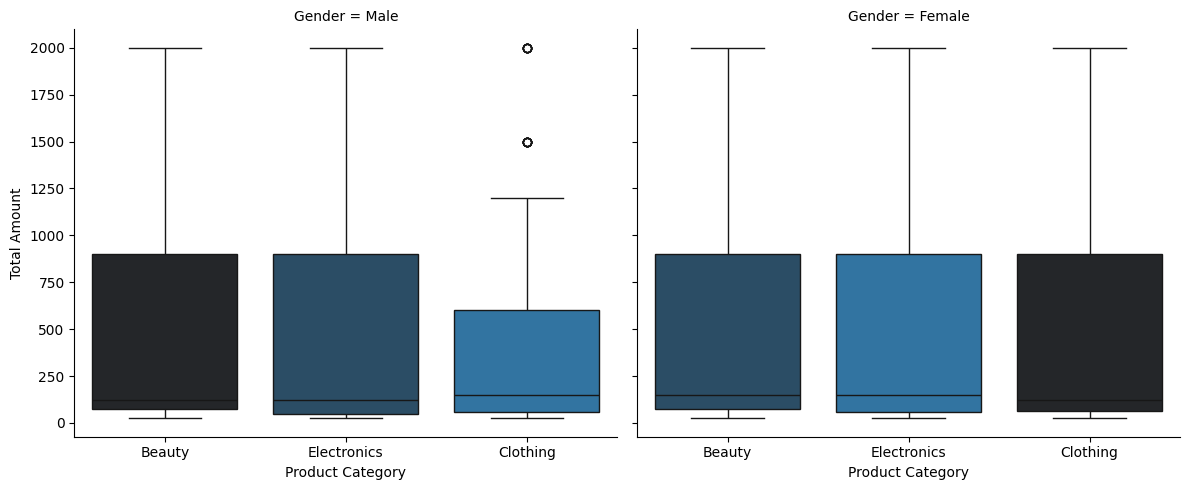

In [69]:
# Plot
# Facet by gender
g = sns.FacetGrid(df, col="Gender", height=5, aspect=1.2)
g.map_dataframe(sns.boxplot, x="Product Category", y="Total Amount", hue="Product Category", palette="dark:#1f77b4")


Berdasarkan hasil visualisasi:

1. Distribusi transaksi antara Male dan Female memiliki pola yang mirip.
2. Rata-rata pengeluaran tidak menunjukkan perbedaan signifikan antara pria dan wanita dalam kategori yang sama.
3. Clothing memiliki perbedaan distribusi antara Male & Female.
4. Perbedaan terlihat pada variabilitas transaksi, di mana Male memiliki lebih banyak outlier dalam kategori Clothing.
  * Untuk Male, terdapat lebih banyak outlier, artinya ada transaksi besar yang cukup ekstrem.
  * Untuk Female, distribusi transaksi Clothing lebih stabil, dengan rentang yang lebih lebar tetapi tanpa outlier signifikan.
5. Electronics dan Beauty memiliki distribusi yang hampir sama untuk Male & Female, yang berarti pola pengeluaran pada kategori ini cenderung konsisten di kedua gender.





